## «Я вернусь позже» — предсказание повторного обращения пользователя

**Предыстория**

При разработке мобильных приложений важно не только привлекать новых пользователей, но и удерживать уже существующих. Виктор и его одногруппник разрабатывают собственное приложение и хотят заранее понимать, вернётся ли пользователь в ближайшее время. Это позволит им вовремя запускать механики удержания — например, отправлять уведомления или специальные предложения.

Виктор подготовил таблицу с агрегированными характеристиками поведения пользователей в приложении: частота использования, длительность сессий и другие показатели активности.

#### Структура `train.csv`

| Признак | Тип | Описание |
|---|---|---|
| `id` | int | идентификатор пользователя |
| `sessions_count` | int | количество сессий за период |
| `avg_session_time` | float | средняя длительность сессии (мин) |
| `days_since_last_activity` | int | дней с последнего визита |
| `purchases_count` | int | количество покупок |
| `avg_purchase_value` | float | средний чек (рубли) |
| `active_days` | int | число активных дней |
| `session_std` | float | разброс длительности сессий |
| `is_weekend_user` | int | чаще активен в выходные (0/1) |
| `retention` | int | целевая переменная |

### Разветка

In [2]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

display(train.shape)
display(test.shape)
display(train.head())
display(test.head())


(7595, 10)

(2532, 9)

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
0,1045,16,46.079173,9,13,5462.010418,18,14.307116,1,0
1,1339,1,42.625268,24,8,4679.746955,14,26.690708,1,1
2,5144,16,67.310472,21,12,6532.157783,21,13.092315,1,1
3,7099,16,78.904027,34,14,7155.049697,28,10.564979,0,0
4,7907,8,50.456513,19,12,6214.569079,25,6.813272,1,0


,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user
0,7001,11,71.085651,31,14,3613.133197,20,12.307634,0
1,1319,9,47.558578,23,13,6189.807969,24,5.585591,1
2,8901,10,79.631917,19,16,7425.979316,16,15.729078,1
3,9175,11,54.990557,21,14,5058.609732,26,9.082133,1
4,350,1,54.626764,3,9,5477.624691,15,11.273880,0


In [7]:
display(train.info())
display(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7595 entries, 0 to 7594
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        7595 non-null   int64  
 1   sessions_count            7595 non-null   int64  
 2   avg_session_time          7595 non-null   float64
 3   days_since_last_activity  7595 non-null   int64  
 4   purchases_count           7595 non-null   int64  
 5   avg_purchase_value        7595 non-null   float64
 6   active_days               7595 non-null   int64  
 7   session_std               7595 non-null   float64
 8   is_weekend_user           7595 non-null   int64  
 9   retention                 7595 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 593.5 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2532 entries, 0 to 2531
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2532 non-null   int64  
 1   sessions_count            2532 non-null   int64  
 2   avg_session_time          2532 non-null   float64
 3   days_since_last_activity  2532 non-null   int64  
 4   purchases_count           2532 non-null   int64  
 5   avg_purchase_value        2532 non-null   float64
 6   active_days               2532 non-null   int64  
 7   session_std               2532 non-null   float64
 8   is_weekend_user           2532 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 178.2 KB


None

In [8]:


display(train.describe().drop(columns=['id']))
display(test.describe().drop(columns=['id']))

,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
count,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000
mean,10.426333,56.822155,19.565240,12.149704,5870.966510,20.233180,11.914057,0.499408,0.732192
std,5.643471,12.014306,9.334608,2.442620,1429.775977,4.144513,3.758870,0.500033,0.442846
min,1.000000,23.731409,0.000000,3.000000,2097.949638,8.000000,0.000000,0.000000,0.000000
25%,7.000000,47.158410,13.000000,11.000000,4780.689415,17.000000,9.497875,0.000000,0.000000
50%,12.000000,54.467435,20.000000,12.000000,5542.283468,20.000000,11.788557,0.000000,1.000000
75%,15.000000,66.069138,26.000000,14.000000,6880.581191,22.000000,14.210551,1.000000,1.000000
max,31.000000,90.000000,55.000000,21.000000,10000.000000,30.000000,30.661213,1.000000,1.000000


,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user
count,2532.000000,2532.000000,2532.000000,2532.000000,2532.000000,2532.000000,2532.000000,2532.000000
mean,10.606240,56.837473,19.821880,12.144155,5899.702341,20.291469,11.927884,0.504344
std,5.545132,12.090905,9.307654,2.367165,1486.855211,4.201037,3.779952,0.500080
min,1.000000,26.582613,0.000000,1.000000,1997.375798,9.000000,0.000000,0.000000
25%,8.000000,47.402531,14.000000,11.000000,4776.095801,17.000000,9.501937,0.000000
50%,12.000000,54.284662,20.000000,12.000000,5567.619192,20.000000,11.887939,1.000000
75%,15.000000,66.259414,26.000000,14.000000,6933.814753,23.000000,14.295687,1.000000
max,30.000000,90.000000,60.000000,19.000000,10000.000000,30.000000,29.702299,1.000000


In [9]:
display(train.isna().sum())
display(test.isna().sum())

id                          0
sessions_count              0
avg_session_time            0
days_since_last_activity    0
purchases_count             0
avg_purchase_value          0
active_days                 0
session_std                 0
is_weekend_user             0
retention                   0
dtype: int64

id                          0
sessions_count              0
avg_session_time            0
days_since_last_activity    0
purchases_count             0
avg_purchase_value          0
active_days                 0
session_std                 0
is_weekend_user             0
dtype: int64

In [10]:
print("Train duplicates:", train.duplicated().sum())
print("Test duplicates:", test.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [11]:
display(train["retention"].value_counts())
display(train["retention"].value_counts(normalize=True))

retention
1    5561
0    2034
Name: count, dtype: int64

retention
1    0.732192
0    0.267808
Name: proportion, dtype: float64

### EDA

#### Структура `train.csv`

| Признак | Тип | Описание |
|---|---|---|
| `id` | int | идентификатор пользователя |
| `sessions_count` | int | количество сессий за период |
| `avg_session_time` | float | средняя длительность сессии (мин) |
| `days_since_last_activity` | int | дней с последнего визита |
| `purchases_count` | int | количество покупок |
| `avg_purchase_value` | float | средний чек (рубли) |
| `active_days` | int | число активных дней |
| `session_std` | float | разброс длительности сессий |
| `is_weekend_user` | int | чаще активен в выходные (0/1) |
| `retention` | int | целевая переменная |`0` = не вернётся                                |


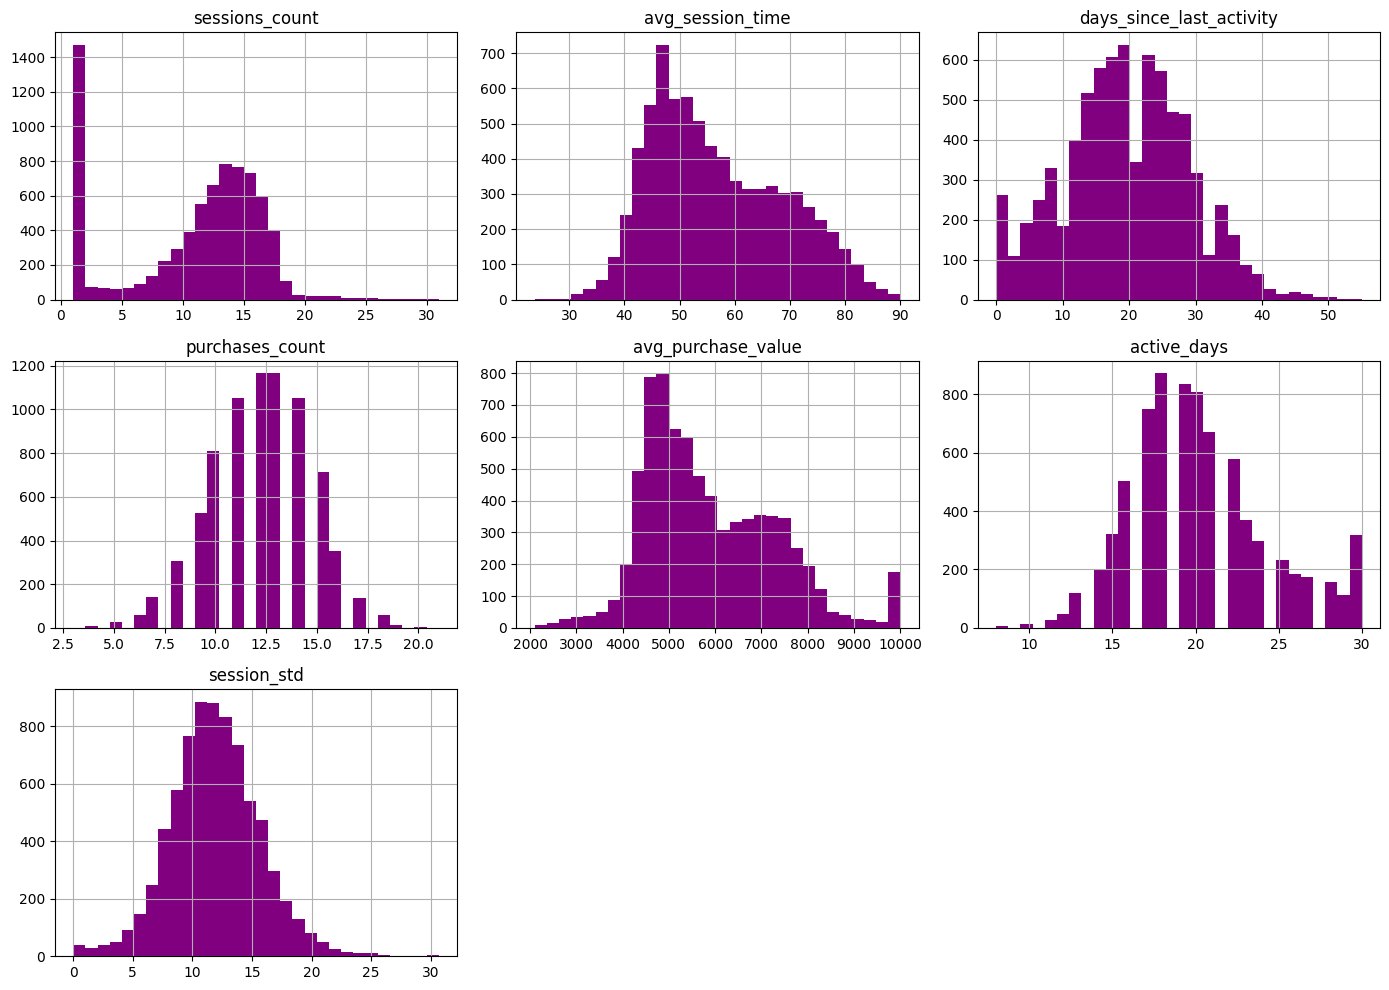

In [12]:
import matplotlib.pyplot as plt

features = [
    "sessions_count",
    "avg_session_time",
    "days_since_last_activity",
    "purchases_count",
    "avg_purchase_value",
    "active_days",
    "session_std"
]

train[features].hist(figsize=(14, 10), color='purple', bins=30)
plt.tight_layout()
plt.show()

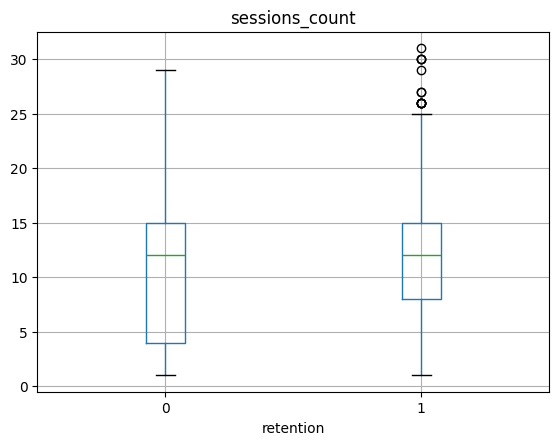

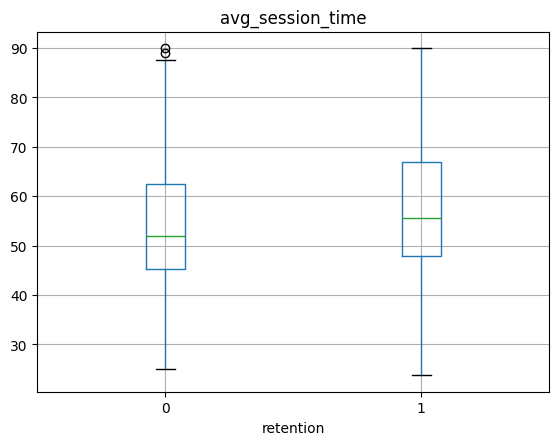

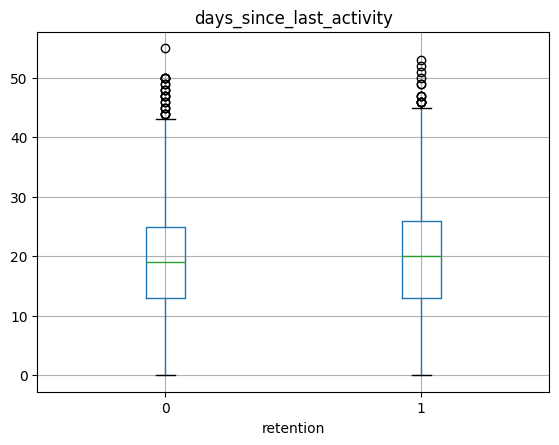

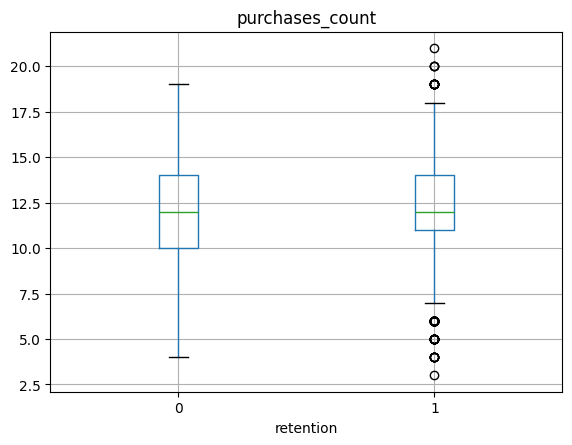

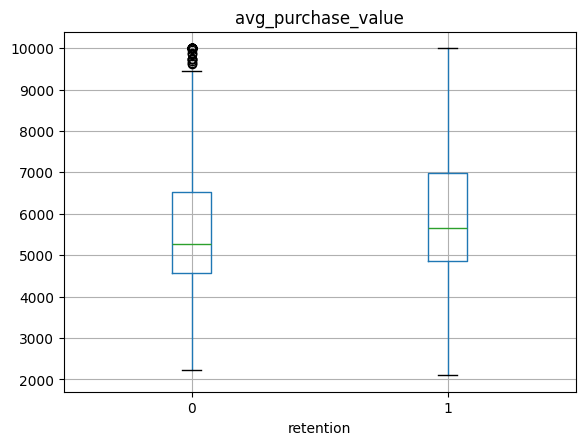

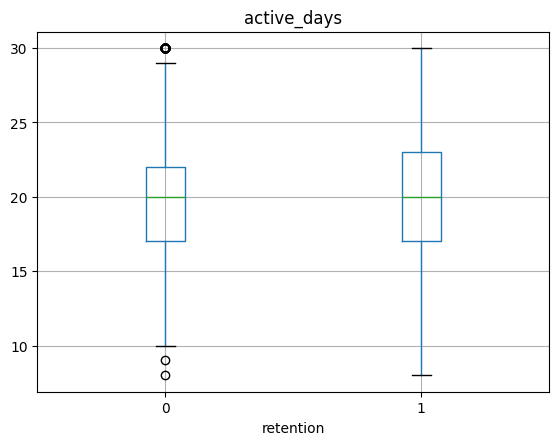

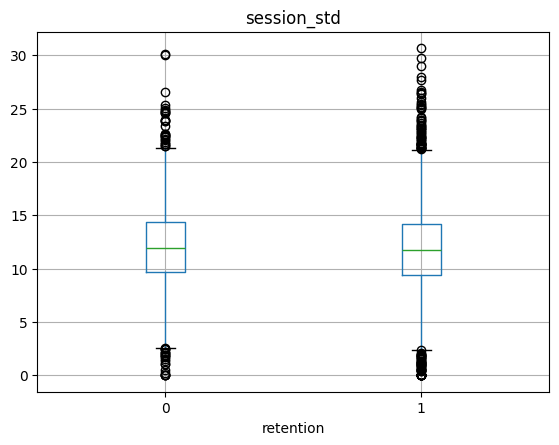

In [13]:
for feature in features:
    train.boxplot(column=feature, by="retention")
    plt.title(feature)
    plt.suptitle("")
    plt.xlabel("retention")
    plt.show()

In [14]:
train.groupby("retention")[features].agg(["mean", "median"])
train.drop(columns="id").corr()["retention"].sort_values(ascending=False)
pd.crosstab(
    train["is_weekend_user"],
    train["retention"],
    normalize="index"
)



retention,0,1
is_weekend_user,,
0,0.245134,0.754866
1,0.290535,0.709465


#### Структура `train.csv`

| Признак | Тип | Описание |
|---|---|---|
| `id` | int | идентификатор пользователя |
| `sessions_count` | int | количество сессий за период |
| `avg_session_time` | float | средняя длительность сессии (мин) |
| `days_since_last_activity` | int | дней с последнего визита |
| `purchases_count` | int | количество покупок |
| `avg_purchase_value` | float | средний чек (рубли) |
| `active_days` | int | число активных дней |
| `session_std` | float | разброс длительности сессий |
| `is_weekend_user` | int | чаще активен в выходные (0/1) |
| `retention` | int | целевая переменная |

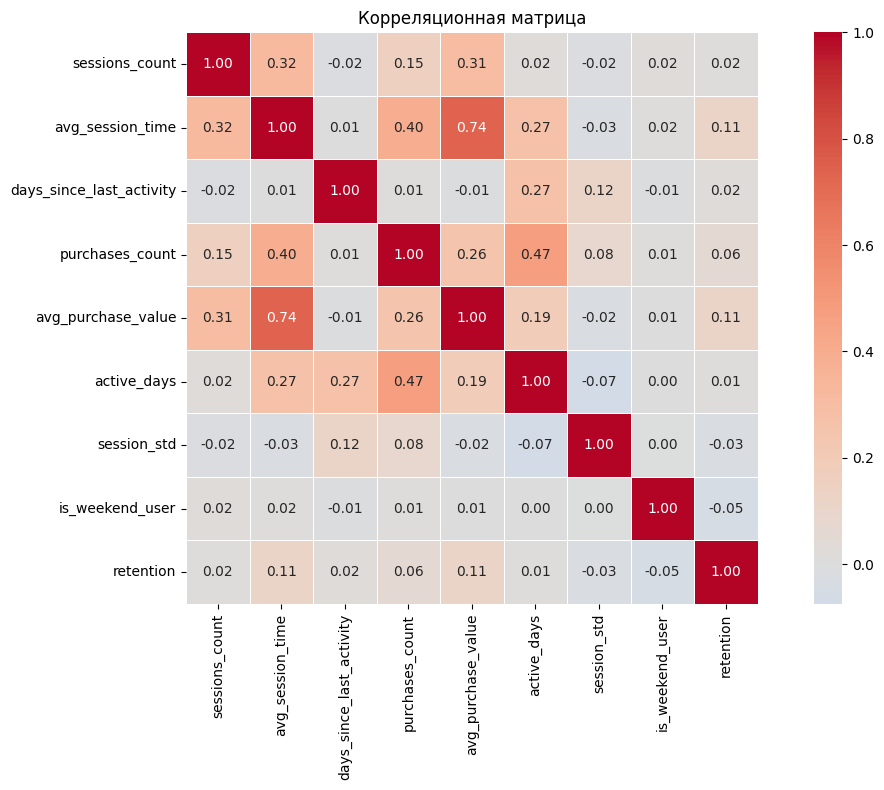

In [15]:
import seaborn as sns

corr = train.drop(columns="id").corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Подготовка данных
X = train.drop(columns=["id", "retention"])
y = train["retention"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Логистическая регрессия
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_prob = logreg.predict_proba(X_val_scaled)[:, 1]
logreg_auc = roc_auc_score(y_val, logreg_prob)

# Дерево решений
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_prob = tree.predict_proba(X_val)[:, 1]
tree_auc = roc_auc_score(y_val, tree_prob)

print(f"Logistic Regression ROC-AUC: {logreg_auc:.4f}")
print(f"Decision Tree ROC-AUC:        {tree_auc:.4f}")


Logistic Regression ROC-AUC: 0.6236
Decision Tree ROC-AUC:        0.6425


In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Feature Engineering
def create_features(data, log_columns):
    data = data.copy()

    for column in log_columns:
        data[f"{column}_log"] = np.log1p(data[column])

    data["sessions_per_active_day"] = (
        data["sessions_count"] / (data["active_days"] + 1)
    )
    data["purchases_per_session"] = (
        data["purchases_count"] / (data["sessions_count"] + 1)
    )
    data["estimated_revenue"] = (
        data["purchases_count"] * data["avg_purchase_value"]
    )

    return data

# Select long-tailed non-negative features using training data only
skewness = X_train.skew(numeric_only=True).abs()
log_columns = [
    column for column in skewness[skewness > 1].index
    if X_train[column].min() >= 0
]

X_train_fe = create_features(X_train, log_columns)
X_val_fe = create_features(X_val, log_columns)

# Models and ROC-AUC evaluation
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_val_fe_scaled = scaler_fe.transform(X_val_fe)

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        X_train_fe_scaled,
        X_val_fe_scaled,
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        X_train_fe,
        X_val_fe,
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.07,
            max_depth=3,
            random_state=42,
        ),
        X_train_fe,
        X_val_fe,
    ),
}

results = {}
for name, (model, train_features, val_features) in models.items():
    model.fit(train_features, y_train)
    probabilities = model.predict_proba(val_features)[:, 1]
    results[name] = roc_auc_score(y_val, probabilities)

results = (
    pd.Series(results, name="ROC-AUC")
    .sort_values(ascending=False)
    .to_frame()
)
results


,ROC-AUC
Random Forest,0.670755
Gradient Boosting,0.667424
Logistic Regression,0.638611


Best Random Forest parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 500}
Random Forest CV ROC-AUC:         0.6693
Random Forest validation ROC-AUC: 0.6748

Best Gradient Boosting parameters: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 100}
Gradient Boosting CV ROC-AUC:         0.6641
Gradient Boosting validation ROC-AUC: 0.6681


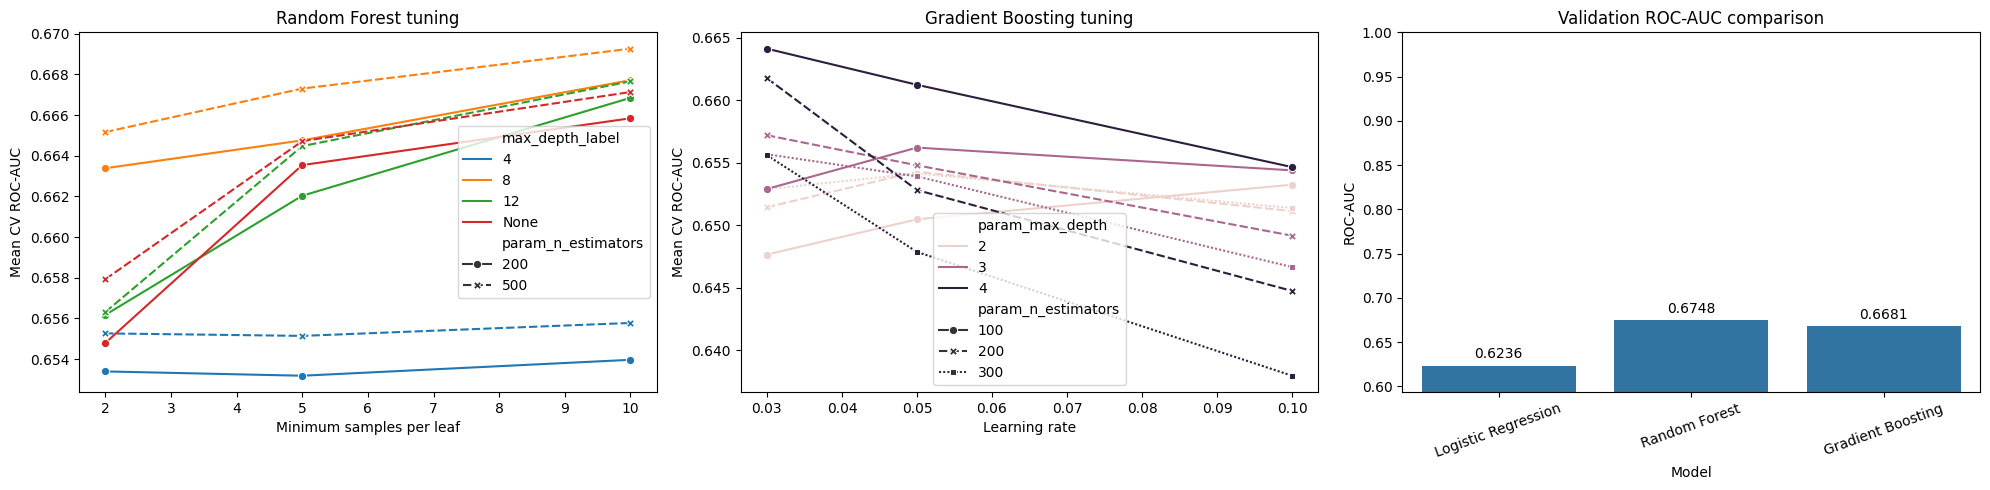

In [18]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning with cross-validation
rf_grid = {
    "n_estimators": [200, 500],
    "max_depth": [4, 8, 12, None],
    "min_samples_leaf": [2, 5, 10],
}

gb_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}

rf_search = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    rf_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)

rf_search.fit(X_train_fe, y_train)
gb_search.fit(X_train_fe, y_train)

# ROC-AUC on the holdout validation set
rf_val_auc = roc_auc_score(
    y_val, rf_search.best_estimator_.predict_proba(X_val_fe)[:, 1]
)
gb_val_auc = roc_auc_score(
    y_val, gb_search.best_estimator_.predict_proba(X_val_fe)[:, 1]
)

print("Best Random Forest parameters:", rf_search.best_params_)
print(f"Random Forest CV ROC-AUC:         {rf_search.best_score_:.4f}")
print(f"Random Forest validation ROC-AUC: {rf_val_auc:.4f}\n")
print("Best Gradient Boosting parameters:", gb_search.best_params_)
print(f"Gradient Boosting CV ROC-AUC:         {gb_search.best_score_:.4f}")
print(f"Gradient Boosting validation ROC-AUC: {gb_val_auc:.4f}")

# Prepare grid-search results for visualization
rf_cv = pd.DataFrame(rf_search.cv_results_)
rf_cv["max_depth_label"] = rf_cv["param_max_depth"].astype(str)

gb_cv = pd.DataFrame(gb_search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.lineplot(
    data=rf_cv,
    x="param_min_samples_leaf",
    y="mean_test_score",
    hue="max_depth_label",
    style="param_n_estimators",
    markers=True,
    ax=axes[0],
)
axes[0].set_title("Random Forest tuning")
axes[0].set_xlabel("Minimum samples per leaf")
axes[0].set_ylabel("Mean CV ROC-AUC")

sns.lineplot(
    data=gb_cv,
    x="param_learning_rate",
    y="mean_test_score",
    hue="param_max_depth",
    style="param_n_estimators",
    markers=True,
    ax=axes[1],
)
axes[1].set_title("Gradient Boosting tuning")
axes[1].set_xlabel("Learning rate")
axes[1].set_ylabel("Mean CV ROC-AUC")

final_scores = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC-AUC": [logreg_auc, rf_val_auc, gb_val_auc],
})
sns.barplot(data=final_scores, x="Model", y="ROC-AUC", ax=axes[2])
axes[2].set_title("Validation ROC-AUC comparison")
axes[2].tick_params(axis="x", rotation=20)
axes[2].set_ylim(max(0.5, final_scores["ROC-AUC"].min() - 0.03), 1.0)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.show()


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CatBoost parameters: {'depth': 6, 'iterations': 808, 'l2_leaf_reg': 12.134211833931419, 'learning_rate': 0.016809415579919437, 'random_strength': 0.7821212151464816}
CatBoost CV ROC-AUC:         0.6699
CatBoost validation ROC-AUC: 0.6808
Best blend ROC-AUC:          0.6810
CatBoost weight in blend:    0.75


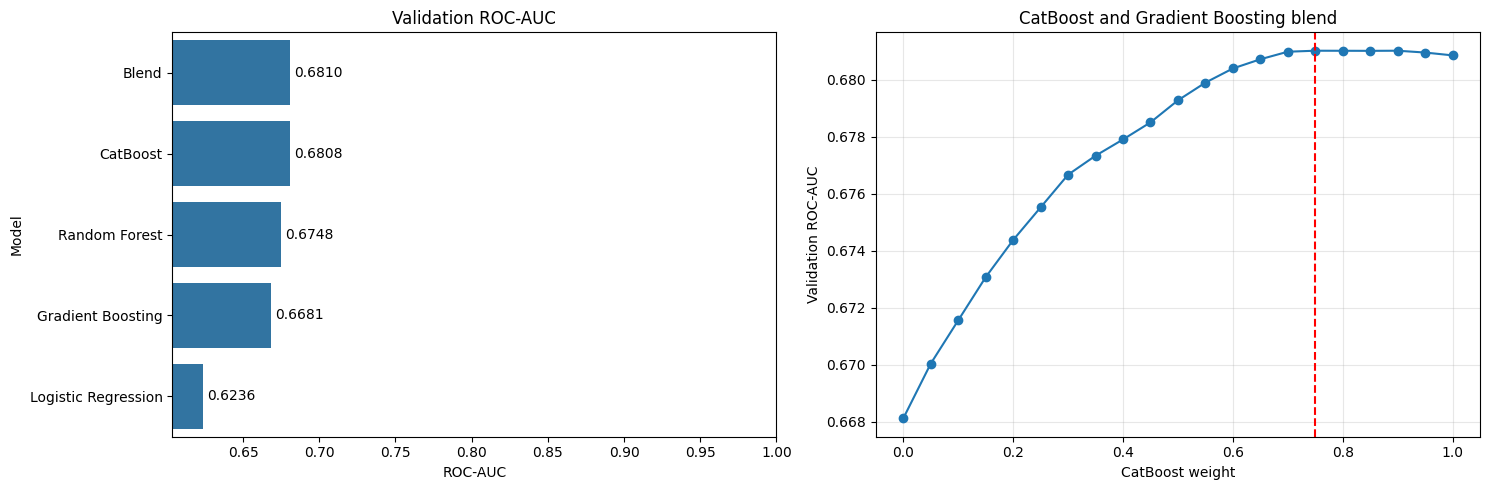

,Model,ROC-AUC
4,Blend,0.681012
3,CatBoost,0.680848
1,Random Forest,0.674752
2,Gradient Boosting,0.668117
0,Logistic Regression,0.623575


In [19]:
from catboost import CatBoostClassifier
from sklearn.model_selection import (
    ParameterSampler, RandomizedSearchCV, StratifiedKFold
)
from scipy.stats import loguniform, randint, uniform

# Extended feature engineering
def create_extended_features(data, log_columns):
    data = create_features(data, log_columns)
    eps = 1e-6

    data["total_session_time"] = (
        data["sessions_count"] * data["avg_session_time"]
    )
    data["session_stability"] = (
        data["avg_session_time"] / (data["session_std"] + eps)
    )
    data["activity_recency_ratio"] = (
        data["active_days"] / (data["days_since_last_activity"] + 1)
    )
    data["has_purchases"] = (data["purchases_count"] > 0).astype(int)
    data["is_inactive_30d"] = (
        data["days_since_last_activity"] >= 30
    ).astype(int)
    data["estimated_revenue_log"] = np.log1p(data["estimated_revenue"])

    return data.replace([np.inf, -np.inf], np.nan).fillna(0)

X_train_ext = create_extended_features(X_train, log_columns)
X_val_ext = create_extended_features(X_val, log_columns)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

catboost = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42,
    thread_count=-1,
)

parameter_distributions = {
    "iterations": randint(300, 1001),
    "depth": randint(3, 9),
    "learning_rate": loguniform(0.01, 0.2),
    "l2_leaf_reg": loguniform(1, 20),
    "random_strength": uniform(0, 2),
}

cat_search = RandomizedSearchCV(
    estimator=catboost,
    param_distributions=parameter_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
)
cat_search.fit(X_train_ext, y_train)

cat_prob = cat_search.best_estimator_.predict_proba(X_val_ext)[:, 1]
cat_auc = roc_auc_score(y_val, cat_prob)

# Blend CatBoost with the best previously tuned boosting model
gb_prob = gb_search.best_estimator_.predict_proba(X_val_fe)[:, 1]
blend_weights = np.arange(0, 1.01, 0.05)
blend_scores = [
    roc_auc_score(y_val, weight * cat_prob + (1 - weight) * gb_prob)
    for weight in blend_weights
]
best_weight = blend_weights[np.argmax(blend_scores)]
best_blend_auc = max(blend_scores)

print("Best CatBoost parameters:", cat_search.best_params_)
print(f"CatBoost CV ROC-AUC:         {cat_search.best_score_:.4f}")
print(f"CatBoost validation ROC-AUC: {cat_auc:.4f}")
print(f"Best blend ROC-AUC:          {best_blend_auc:.4f}")
print(f"CatBoost weight in blend:    {best_weight:.2f}")

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Random Forest",
        "Gradient Boosting", "CatBoost", "Blend"
    ],
    "ROC-AUC": [
        logreg_auc, rf_val_auc, gb_val_auc, cat_auc, best_blend_auc
    ],
}).sort_values("ROC-AUC", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=comparison, x="ROC-AUC", y="Model", ax=axes[0])
axes[0].set_title("Validation ROC-AUC")
axes[0].set_xlim(max(0.5, comparison["ROC-AUC"].min() - 0.02), 1.0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f", padding=3)

axes[1].plot(blend_weights, blend_scores, marker="o")
axes[1].axvline(best_weight, color="red", linestyle="--")
axes[1].set_title("CatBoost and Gradient Boosting blend")
axes[1].set_xlabel("CatBoost weight")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

comparison


In [20]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

# Итоговая конфигурация CatBoost, давшая ROC-AUC около 0.6808
X_train_final = create_extended_features(X_train, log_columns)
X_val_final = create_extended_features(X_val, log_columns)

final_model = CatBoostClassifier(
    iterations=808,
    depth=6,
    learning_rate=0.0165,
    l2_leaf_reg=12.1,
    random_strength=0.75,
    loss_function="Logloss",
    random_seed=42,
    eval_metric="AUC",
    verbose=False,
    allow_writing_files=False,
)

final_model.fit(X_train_final, y_train)
final_probability = final_model.predict_proba(X_val_final)[:, 1]
final_roc_auc = roc_auc_score(y_val, final_probability)

print(f"Final CatBoost ROC-AUC: {final_roc_auc:.4f}")


Final CatBoost ROC-AUC: 0.6781


In [ ]:
import os
from getpass import getpass

import torch
from tabpfn import TabPFNClassifier
from sklearn.metrics import roc_auc_score

# One-time authorization for downloading the licensed TabPFN weights
if not os.environ.get("TABPFN_TOKEN"):
    print("1. Open https://ux.priorlabs.ai")
    print("2. Sign in and accept the license on the Licenses tab")
    print("3. Copy the API key from https://ux.priorlabs.ai/account")
    os.environ["TABPFN_TOKEN"] = getpass("Paste TABPFN_TOKEN: " )

# TabPFN on the same validation split as CatBoost
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"TabPFN device: {device}")

X_train_tabpfn = X_train.astype(np.float32)
X_val_tabpfn = X_val.astype(np.float32)

tabpfn_model = TabPFNClassifier(device=device)
tabpfn_model.fit(X_train_tabpfn, y_train)
tabpfn_probability = tabpfn_model.predict_proba(X_val_tabpfn)[:, 1]
tabpfn_auc = roc_auc_score(y_val, tabpfn_probability)

print(f"TabPFN ROC-AUC:   {tabpfn_auc:.4f}")
print(f"CatBoost ROC-AUC: {final_roc_auc:.4f}")


1. Open https://ux.priorlabs.ai
2. Sign in and accept the license on the Licenses tab
3. Copy the API key from https://ux.priorlabs.ai/account


## Новый чистый эксперимент: предобработка → baseline → Feature Engineering → PCA → сложные модели

Все модели сравниваются на одном и том же стратифицированном validation split по ROC-AUC.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

redo_target = "retention"
redo_id = "id"
redo_features = [c for c in train.columns if c not in [redo_id, redo_target]]

missing_report = train[redo_features + [redo_target]].isna().sum().to_frame("missing")
missing_report["missing_%"] = 100 * missing_report["missing"] / len(train)

impossible_checks = pd.Series({
    "negative_sessions": (train["sessions_count"] < 0).sum(),
    "negative_session_time": (train["avg_session_time"] < 0).sum(),
    "session_time_over_24h": (train["avg_session_time"] > 24 * 60).sum(),
    "negative_purchases": (train["purchases_count"] < 0).sum(),
    "negative_purchase_value": (train["avg_purchase_value"] < 0).sum(),
    "negative_active_days": (train["active_days"] < 0).sum(),
    "invalid_weekend_flag": (~train["is_weekend_user"].isin([0, 1])).sum(),
}, name="count")

outlier_rows = []
for column in redo_features:
    q1, q3 = train[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_rows.append({
        "feature": column,
        "min": train[column].min(),
        "max": train[column].max(),
        "IQR outliers": ((train[column] < lower) | (train[column] > upper)).sum(),
        "skew": train[column].skew(),
    })
outlier_report = pd.DataFrame(outlier_rows).sort_values("IQR outliers", ascending=False)

print("Missing values:")
display(missing_report)
print("Impossible values:")
display(impossible_checks.to_frame())
print("Outliers and skewness:")
display(outlier_report)


Missing values:


,missing,missing_%
sessions_count,0,0.0
avg_session_time,0,0.0
days_since_last_activity,0,0.0
purchases_count,0,0.0
avg_purchase_value,0,0.0
active_days,0,0.0
session_std,0,0.0
is_weekend_user,0,0.0
retention,0,0.0


Impossible values:


,count
negative_sessions,0
negative_session_time,0
session_time_over_24h,0
negative_purchases,0
negative_purchase_value,0
negative_active_days,0
invalid_weekend_flag,0


Outliers and skewness:


,feature,min,max,IQR outliers,skew
5,active_days,8.000000,30.000000,325,0.561592
6,session_std,0.000000,30.661213,162,0.175379
3,purchases_count,3.000000,21.000000,113,-0.179127
2,days_since_last_activity,0.000000,55.000000,31,0.065760
0,sessions_count,1.000000,31.000000,8,-0.525392
1,avg_session_time,23.731409,90.000000,0,0.441930
4,avg_purchase_value,2097.949638,10000.000000,0,0.688361
7,is_weekend_user,0.000000,1.000000,0,0.002370


In [4]:
from sklearn.model_selection import train_test_split

redo_X = train[redo_features].copy()
redo_y = train[redo_target].copy()

redo_X_train, redo_X_val, redo_y_train, redo_y_val = train_test_split(
    redo_X, redo_y, test_size=0.2, random_state=42, stratify=redo_y
)

# Пороги вычисляются только по train-части, чтобы не было утечки
redo_clip_limits = {
    column: (
        redo_X_train[column].quantile(0.005),
        redo_X_train[column].quantile(0.995),
    )
    for column in redo_features
}

redo_skew = redo_X_train.skew(numeric_only=True).abs()
redo_log_columns = [
    column for column in redo_skew[redo_skew > 0.5].index
    if redo_X_train[column].min() >= 0 and column != "is_weekend_user"
]
print("Log-transform candidates:", redo_log_columns)
print("Train shape:", redo_X_train.shape, "Validation shape:", redo_X_val.shape)


Log-transform candidates: ['sessions_count', 'avg_purchase_value', 'active_days']
Train shape: (6076, 8) Validation shape: (1519, 8)


In [5]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

redo_models = {}
redo_results = []

redo_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])
redo_tree = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=10, random_state=42
)

for name, model in {
    "Logistic Regression baseline": redo_logistic,
    "Decision Tree baseline": redo_tree,
}.items():
    model.fit(redo_X_train, redo_y_train)
    probability = model.predict_proba(redo_X_val)[:, 1]
    auc = roc_auc_score(redo_y_val, probability)
    redo_models[name] = model
    redo_results.append({"Model": name, "ROC-AUC": auc})
    print(f"{name}: {auc:.4f}")


Logistic Regression baseline: 0.6236
Decision Tree baseline: 0.6476


In [6]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def redo_engineer(data):
    result = data.copy()
    for column, (lower, upper) in redo_clip_limits.items():
        result[column] = result[column].clip(lower, upper)
    for column in redo_log_columns:
        result[f"{column}_log"] = np.log1p(result[column])
    result["sessions_per_active_day"] = (
        result["sessions_count"] / (result["active_days"] + 1)
    )
    result["purchases_per_session"] = (
        result["purchases_count"] / (result["sessions_count"] + 1)
    )
    result["estimated_revenue"] = (
        result["purchases_count"] * result["avg_purchase_value"]
    )
    return result.replace([np.inf, -np.inf], np.nan)

redo_X_train_fe = redo_engineer(redo_X_train)
redo_X_val_fe = redo_engineer(redo_X_val)
redo_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

redo_lr_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])
redo_lr_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])

redo_linear_searches = {
    "Logistic + Feature Engineering": GridSearchCV(
        redo_lr_fe, {"model__C": [0.01, 0.1, 1, 10]},
        scoring="roc_auc", cv=redo_cv, n_jobs=-1
    ),
    "Logistic + Feature Engineering + PCA": GridSearchCV(
        redo_lr_pca,
        {"pca__n_components": [0.80, 0.90, 0.95, 0.99],
         "model__C": [0.01, 0.1, 1, 10]},
        scoring="roc_auc", cv=redo_cv, n_jobs=-1
    ),
}

for name, search in redo_linear_searches.items():
    search.fit(redo_X_train_fe, redo_y_train)
    probability = search.best_estimator_.predict_proba(redo_X_val_fe)[:, 1]
    auc = roc_auc_score(redo_y_val, probability)
    redo_models[name] = search.best_estimator_
    redo_results.append({"Model": name, "ROC-AUC": auc})
    print(f"{name}: {auc:.4f}; params={search.best_params_}")


Logistic + Feature Engineering: 0.6268; params={'model__C': 10}
Logistic + Feature Engineering + PCA: 0.6396; params={'model__C': 1, 'pca__n_components': 0.99}


Random Forest: 0.6762
Gradient Boosting: 0.6687


,Model,ROC-AUC
0,Random Forest,0.676177
1,Gradient Boosting,0.668718
2,Decision Tree baseline,0.647618
3,Logistic + Feature Engineering + PCA,0.639640
4,Logistic + Feature Engineering,0.626783
5,Logistic Regression baseline,0.623575


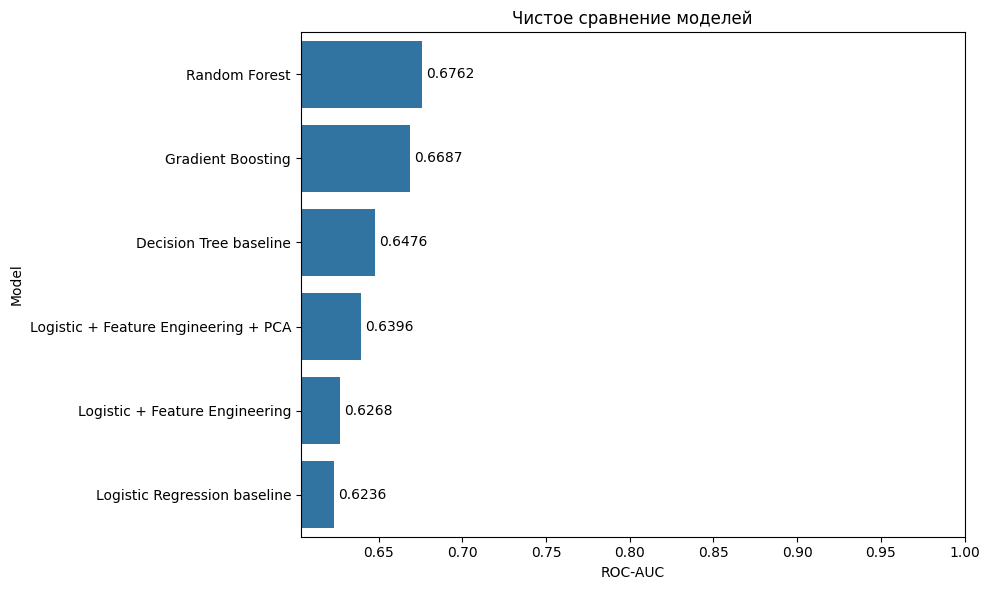

In [7]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

redo_complex_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=600, max_depth=10, min_samples_leaf=5,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.03, max_depth=3,
        min_samples_leaf=10, subsample=0.8, random_state=42,
    ),
}

for name, model in redo_complex_models.items():
    model.fit(redo_X_train_fe.fillna(redo_X_train_fe.median()), redo_y_train)
    probability = model.predict_proba(
        redo_X_val_fe.fillna(redo_X_train_fe.median())
    )[:, 1]
    auc = roc_auc_score(redo_y_val, probability)
    redo_models[name] = model
    redo_results.append({"Model": name, "ROC-AUC": auc})
    print(f"{name}: {auc:.4f}")

redo_results_df = (
    pd.DataFrame(redo_results)
    .drop_duplicates("Model", keep="last")
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
display(redo_results_df)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=redo_results_df, x="ROC-AUC", y="Model")
ax.set_title("Чистое сравнение моделей")
ax.set_xlim(max(0.5, redo_results_df["ROC-AUC"].min() - 0.02), 1.0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.tight_layout()
plt.show()


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Polynomial interactions on top of clipped and log-transformed features
redo_poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42)),
])

redo_poly_search = GridSearchCV(
    redo_poly_pipeline,
    param_grid={
        "polynomial__degree": [2, 3],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
    },
    scoring="roc_auc",
    cv=redo_cv,
    n_jobs=-1,
)
redo_poly_search.fit(redo_X_train_fe, redo_y_train)
redo_poly_probability = redo_poly_search.best_estimator_.predict_proba(
    redo_X_val_fe
)[:, 1]
redo_poly_auc = roc_auc_score(redo_y_val, redo_poly_probability)

print("Best parameters:", redo_poly_search.best_params_)
print(f"Polynomial + log CV ROC-AUC: {redo_poly_search.best_score_:.4f}")
print(f"Polynomial + log validation ROC-AUC: {redo_poly_auc:.4f}")


Best parameters: {'model__C': 0.1, 'polynomial__degree': 3}
Polynomial + log CV ROC-AUC: 0.6526
Polynomial + log validation ROC-AUC: 0.6520


Random Forest: OOF=0.6672, validation=0.6760
CatBoost: OOF=0.6719, validation=0.6760
Gradient Boosting: OOF=0.6602, validation=0.6680

Weights selected by OOF:


,Weight
Random Forest,0.25
CatBoost,0.75
Gradient Boosting,0.00


Blend OOF ROC-AUC: 0.6726
Blend validation ROC-AUC: 0.6769


,Model,Validation ROC-AUC
3,OOF Blend,0.676869
1,CatBoost,0.676016
0,Random Forest,0.675976
2,Gradient Boosting,0.668000


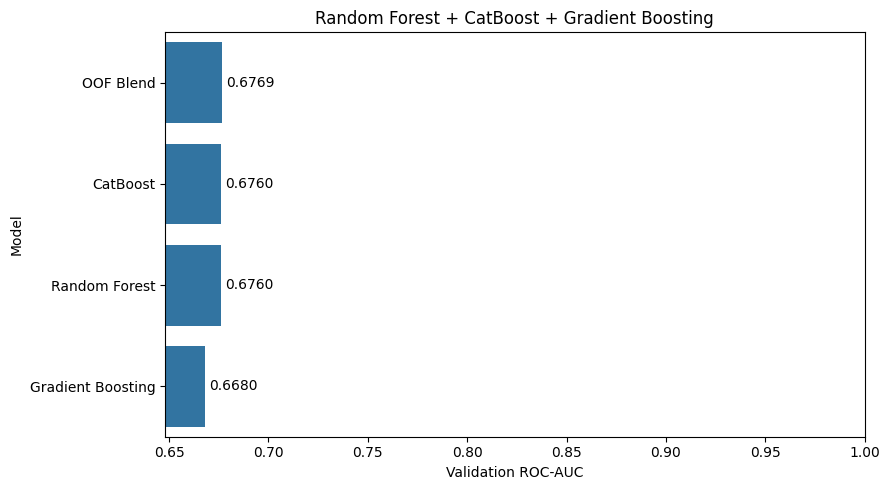

In [10]:
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

redo_train_median = redo_X_train_fe.median()
redo_train_blend = redo_X_train_fe.fillna(redo_train_median)
redo_val_blend = redo_X_val_fe.fillna(redo_train_median)
redo_blend_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_redo_blend_model(name):
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=600, max_depth=10, min_samples_leaf=5,
            max_features="sqrt", class_weight="balanced",
            random_state=42, n_jobs=-1,
        )
    if name == "Gradient Boosting":
        return GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.03, max_depth=3,
            min_samples_leaf=10, subsample=0.8, random_state=42,
        )
    return CatBoostClassifier(
        iterations=808, depth=6, learning_rate=0.016809415579919437,
        l2_leaf_reg=12.134211833931419,
        random_strength=0.7821212151464816,
        loss_function="Logloss", eval_metric="AUC",
        random_seed=42, verbose=False, allow_writing_files=False,
        thread_count=-1,
    )

redo_blend_names = ["Random Forest", "CatBoost", "Gradient Boosting"]
redo_oof = np.zeros((len(redo_train_blend), len(redo_blend_names)))
redo_val_predictions = np.zeros((len(redo_val_blend), len(redo_blend_names)))

for model_index, model_name in enumerate(redo_blend_names):
    validation_folds = []
    for train_idx, valid_idx in redo_blend_cv.split(
        redo_train_blend, redo_y_train
    ):
        model = make_redo_blend_model(model_name)
        model.fit(redo_train_blend.iloc[train_idx], redo_y_train.iloc[train_idx])
        redo_oof[valid_idx, model_index] = model.predict_proba(
            redo_train_blend.iloc[valid_idx]
        )[:, 1]
        validation_folds.append(model.predict_proba(redo_val_blend)[:, 1])
    redo_val_predictions[:, model_index] = np.mean(validation_folds, axis=0)
    print(
        f"{model_name}: OOF={roc_auc_score(redo_y_train, redo_oof[:, model_index]):.4f}, "
        f"validation={roc_auc_score(redo_y_val, redo_val_predictions[:, model_index]):.4f}"
    )

# Non-negative weights with step 0.05; selection uses OOF predictions only
redo_weight_candidates = []
for rf_step in range(21):
    for cb_step in range(21 - rf_step):
        gb_step = 20 - rf_step - cb_step
        weights = np.array([rf_step, cb_step, gb_step], dtype=float) / 20
        oof_auc = roc_auc_score(redo_y_train, redo_oof @ weights)
        redo_weight_candidates.append((oof_auc, weights))

redo_best_oof_auc, redo_best_weights = max(
    redo_weight_candidates, key=lambda item: item[0]
)
redo_blend_probability = redo_val_predictions @ redo_best_weights
redo_blend_auc = roc_auc_score(redo_y_val, redo_blend_probability)

redo_blend_results = pd.DataFrame({
    "Model": redo_blend_names + ["OOF Blend"],
    "Validation ROC-AUC": [
        *[roc_auc_score(redo_y_val, redo_val_predictions[:, i])
          for i in range(len(redo_blend_names))],
        redo_blend_auc,
    ],
}).sort_values("Validation ROC-AUC", ascending=False)

print("\nWeights selected by OOF:")
display(pd.Series(redo_best_weights, index=redo_blend_names, name="Weight").to_frame())
print(f"Blend OOF ROC-AUC: {redo_best_oof_auc:.4f}")
print(f"Blend validation ROC-AUC: {redo_blend_auc:.4f}")
display(redo_blend_results)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=redo_blend_results, x="Validation ROC-AUC", y="Model"
)
ax.set_title("Random Forest + CatBoost + Gradient Boosting")
ax.set_xlim(
    max(0.5, redo_blend_results["Validation ROC-AUC"].min() - 0.02), 1.0
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.tight_layout()
plt.show()


CatBoost weight selected by OOF: 0.775


,Model,OOF ROC-AUC,Validation ROC-AUC
2,OOF Blend without clipping,0.673915,0.677602
0,CatBoost,0.673140,0.677362
1,Random Forest,0.667421,0.675349


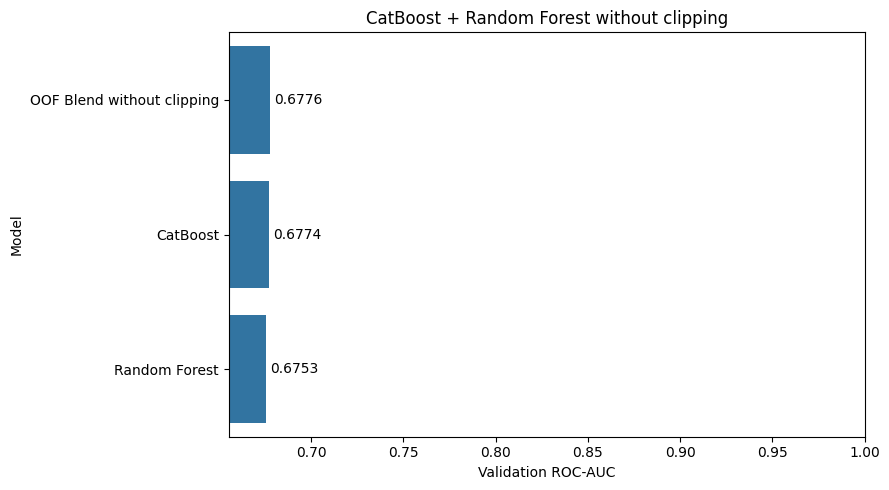

In [11]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Feature engineering without clipping extreme values
def redo_engineer_without_clipping(data):
    result = data.copy()
    for column in redo_log_columns:
        result[f"{column}_log"] = np.log1p(result[column])
    result["sessions_per_active_day"] = (
        result["sessions_count"] / (result["active_days"] + 1)
    )
    result["purchases_per_session"] = (
        result["purchases_count"] / (result["sessions_count"] + 1)
    )
    result["estimated_revenue"] = (
        result["purchases_count"] * result["avg_purchase_value"]
    )
    return result.replace([np.inf, -np.inf], np.nan)

redo_X_train_nc = redo_engineer_without_clipping(redo_X_train)
redo_X_val_nc = redo_engineer_without_clipping(redo_X_val)
redo_nc_median = redo_X_train_nc.median()
redo_X_train_nc = redo_X_train_nc.fillna(redo_nc_median)
redo_X_val_nc = redo_X_val_nc.fillna(redo_nc_median)
redo_nc_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_nc_model(name):
    if name == "CatBoost":
        return CatBoostClassifier(
            iterations=808, depth=6, learning_rate=0.016809415579919437,
            l2_leaf_reg=12.134211833931419,
            random_strength=0.7821212151464816,
            loss_function="Logloss", eval_metric="AUC",
            random_seed=42, verbose=False, allow_writing_files=False,
            thread_count=-1,
        )
    return RandomForestClassifier(
        n_estimators=600, max_depth=10, min_samples_leaf=5,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1,
    )

redo_nc_names = ["CatBoost", "Random Forest"]
redo_nc_oof = np.zeros((len(redo_X_train_nc), 2))
redo_nc_val = np.zeros((len(redo_X_val_nc), 2))

for model_index, model_name in enumerate(redo_nc_names):
    validation_folds = []
    for train_idx, valid_idx in redo_nc_cv.split(redo_X_train_nc, redo_y_train):
        model = make_nc_model(model_name)
        model.fit(redo_X_train_nc.iloc[train_idx], redo_y_train.iloc[train_idx])
        redo_nc_oof[valid_idx, model_index] = model.predict_proba(
            redo_X_train_nc.iloc[valid_idx]
        )[:, 1]
        validation_folds.append(model.predict_proba(redo_X_val_nc)[:, 1])
    redo_nc_val[:, model_index] = np.mean(validation_folds, axis=0)

redo_nc_weights = np.arange(0, 1.001, 0.025)
redo_nc_oof_scores = [
    roc_auc_score(
        redo_y_train,
        weight * redo_nc_oof[:, 0] + (1 - weight) * redo_nc_oof[:, 1],
    )
    for weight in redo_nc_weights
]
redo_nc_best_weight = float(redo_nc_weights[np.argmax(redo_nc_oof_scores)])
redo_nc_blend_probability = (
    redo_nc_best_weight * redo_nc_val[:, 0]
    + (1 - redo_nc_best_weight) * redo_nc_val[:, 1]
)

redo_nc_results = pd.DataFrame({
    "Model": ["CatBoost", "Random Forest", "OOF Blend without clipping"],
    "OOF ROC-AUC": [
        roc_auc_score(redo_y_train, redo_nc_oof[:, 0]),
        roc_auc_score(redo_y_train, redo_nc_oof[:, 1]),
        max(redo_nc_oof_scores),
    ],
    "Validation ROC-AUC": [
        roc_auc_score(redo_y_val, redo_nc_val[:, 0]),
        roc_auc_score(redo_y_val, redo_nc_val[:, 1]),
        roc_auc_score(redo_y_val, redo_nc_blend_probability),
    ],
}).sort_values("Validation ROC-AUC", ascending=False)

print(f"CatBoost weight selected by OOF: {redo_nc_best_weight:.3f}")
display(redo_nc_results)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=redo_nc_results, x="Validation ROC-AUC", y="Model"
)
ax.set_title("CatBoost + Random Forest without clipping")
ax.set_xlim(max(0.5, redo_nc_results["Validation ROC-AUC"].min() - 0.02), 1.0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.tight_layout()
plt.show()


In [12]:
# Train the selected CatBoost + Random Forest blend on all train data
redo_full_X = train[redo_features].copy()
redo_test_X = test[redo_features].copy()
redo_full_y = train[redo_target].copy()

redo_full_skew = redo_full_X.skew(numeric_only=True).abs()
redo_full_log_columns = [
    column for column in redo_full_skew[redo_full_skew > 0.5].index
    if redo_full_X[column].min() >= 0 and column != "is_weekend_user"
]

def final_engineer_without_clipping(data):
    result = data.copy()
    for column in redo_full_log_columns:
        result[f"{column}_log"] = np.log1p(result[column])
    result["sessions_per_active_day"] = (
        result["sessions_count"] / (result["active_days"] + 1)
    )
    result["purchases_per_session"] = (
        result["purchases_count"] / (result["sessions_count"] + 1)
    )
    result["estimated_revenue"] = (
        result["purchases_count"] * result["avg_purchase_value"]
    )
    return result.replace([np.inf, -np.inf], np.nan)

redo_full_final = final_engineer_without_clipping(redo_full_X)
redo_test_final = final_engineer_without_clipping(redo_test_X)
redo_full_median = redo_full_final.median()
redo_full_final = redo_full_final.fillna(redo_full_median)
redo_test_final = redo_test_final.fillna(redo_full_median)

final_blend_catboost = make_nc_model("CatBoost")
final_blend_forest = make_nc_model("Random Forest")
final_blend_catboost.fit(redo_full_final, redo_full_y)
final_blend_forest.fit(redo_full_final, redo_full_y)

final_cb_test_probability = final_blend_catboost.predict_proba(redo_test_final)[:, 1]
final_rf_test_probability = final_blend_forest.predict_proba(redo_test_final)[:, 1]
final_test_probability = (
    redo_nc_best_weight * final_cb_test_probability
    + (1 - redo_nc_best_weight) * final_rf_test_probability
)

final_submission = pd.read_csv("sample_submission.csv")
final_submission["id"] = test["id"].values
final_submission["retention"] = final_test_probability
final_submission.to_csv("catboost_rf_blend_submission.csv", index=False)

print(f"CatBoost weight: {redo_nc_best_weight:.3f}")
print(f"Random Forest weight: {1 - redo_nc_best_weight:.3f}")
print("Saved: catboost_rf_blend_submission.csv")
display(final_submission.head())


CatBoost weight: 0.775
Random Forest weight: 0.225
Saved: catboost_rf_blend_submission.csv


,id,retention
0,7001,0.685858
1,1319,0.631287
2,8901,0.758631
3,9175,0.681647
4,350,0.828871


Best average result:


,Family,Model,mean,std,min,max
0,CatBoost,CB tuned,0.677010,0.014974,0.663872,0.700840
1,CatBoost,CB deep regularized,0.675752,0.012475,0.661451,0.694770
2,CatBoost,CB balanced,0.675471,0.014138,0.660174,0.697904
3,Random Forest,RF current,0.673742,0.012619,0.660381,0.693385
4,CatBoost,CB shallow,0.673497,0.014302,0.659268,0.695756
5,Random Forest,RF shallow,0.671898,0.017166,0.655337,0.699194
6,Random Forest,RF deep regularized,0.666725,0.015418,0.652204,0.691288
7,Random Forest,RF balanced,0.665582,0.016441,0.649703,0.691487


Best CatBoost params:
CB tuned {'iterations': 808, 'depth': 6, 'learning_rate': 0.016809415579919437, 'l2_leaf_reg': 12.134211833931419, 'random_strength': 0.7821212151464816}
Best Random Forest params:
RF current {'n_estimators': 600, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


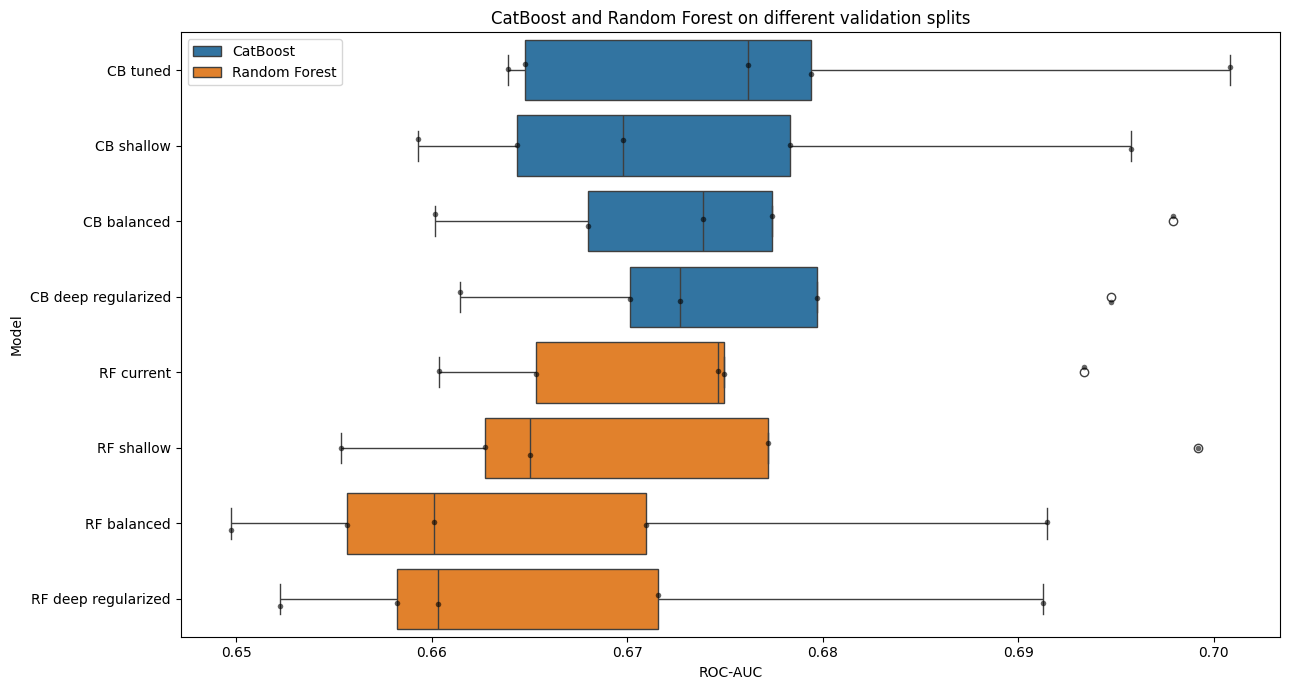

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Compare parameter sets on several independent validation splits
repeat_X = final_engineer_without_clipping(train[redo_features].copy())
repeat_X = repeat_X.fillna(repeat_X.median())
repeat_y = train[redo_target].copy()
validation_seeds = [11, 21, 42, 77, 101]

catboost_parameter_sets = {
    "CB tuned": {
        "iterations": 808, "depth": 6,
        "learning_rate": 0.016809415579919437,
        "l2_leaf_reg": 12.134211833931419,
        "random_strength": 0.7821212151464816,
    },
    "CB shallow": {
        "iterations": 500, "depth": 4, "learning_rate": 0.05,
        "l2_leaf_reg": 8, "random_strength": 0.5,
    },
    "CB balanced": {
        "iterations": 700, "depth": 5, "learning_rate": 0.03,
        "l2_leaf_reg": 15, "random_strength": 1.0,
    },
    "CB deep regularized": {
        "iterations": 500, "depth": 8, "learning_rate": 0.025,
        "l2_leaf_reg": 25, "random_strength": 1.5,
        "bagging_temperature": 0.5,
    },
}

rf_parameter_sets = {
    "RF current": {
        "n_estimators": 600, "max_depth": 10,
        "min_samples_split": 2, "min_samples_leaf": 5,
        "max_features": "sqrt",
    },
    "RF shallow": {
        "n_estimators": 600, "max_depth": 6,
        "min_samples_split": 10, "min_samples_leaf": 10,
        "max_features": 0.75,
    },
    "RF balanced": {
        "n_estimators": 800, "max_depth": 12,
        "min_samples_split": 10, "min_samples_leaf": 5,
        "max_features": 0.75,
    },
    "RF deep regularized": {
        "n_estimators": 800, "max_depth": 16,
        "min_samples_split": 20, "min_samples_leaf": 8,
        "max_features": 1.0,
    },
}

repeated_rows = []
for split_seed in validation_seeds:
    train_idx, valid_idx = train_test_split(
        np.arange(len(repeat_X)),
        test_size=0.2,
        random_state=split_seed,
        stratify=repeat_y,
    )
    X_fit, X_holdout = repeat_X.iloc[train_idx], repeat_X.iloc[valid_idx]
    y_fit, y_holdout = repeat_y.iloc[train_idx], repeat_y.iloc[valid_idx]

    for model_name, params in catboost_parameter_sets.items():
        model = CatBoostClassifier(
            **params, loss_function="Logloss", eval_metric="AUC",
            random_seed=42, verbose=False, allow_writing_files=False,
            thread_count=-1,
        )
        model.fit(X_fit, y_fit)
        auc = roc_auc_score(y_holdout, model.predict_proba(X_holdout)[:, 1])
        repeated_rows.append({
            "Model": model_name, "Family": "CatBoost",
            "Validation seed": split_seed, "ROC-AUC": auc,
        })

    for model_name, params in rf_parameter_sets.items():
        model = RandomForestClassifier(
            **params, class_weight="balanced",
            random_state=42, n_jobs=-1,
        )
        model.fit(X_fit, y_fit)
        auc = roc_auc_score(y_holdout, model.predict_proba(X_holdout)[:, 1])
        repeated_rows.append({
            "Model": model_name, "Family": "Random Forest",
            "Validation seed": split_seed, "ROC-AUC": auc,
        })

repeated_validation_results = pd.DataFrame(repeated_rows)
repeated_summary = (
    repeated_validation_results.groupby(["Family", "Model"])["ROC-AUC"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

print("Best average result:")
display(repeated_summary)
print("Best CatBoost params:")
best_cb_repeat = repeated_summary.query("Family == 'CatBoost'").iloc[0]["Model"]
print(best_cb_repeat, catboost_parameter_sets[best_cb_repeat])
print("Best Random Forest params:")
best_rf_repeat = repeated_summary.query("Family == 'Random Forest'").iloc[0]["Model"]
print(best_rf_repeat, rf_parameter_sets[best_rf_repeat])

plt.figure(figsize=(13, 7))
sns.boxplot(
    data=repeated_validation_results, x="ROC-AUC", y="Model", hue="Family"
)
sns.stripplot(
    data=repeated_validation_results, x="ROC-AUC", y="Model",
    color="black", size=4, alpha=0.6
)
plt.title("CatBoost and Random Forest on different validation splits")
plt.tight_layout()
plt.show()


In [14]:
# Final tuned CatBoost trained on all available labeled data
final_tuned_X = final_engineer_without_clipping(train[redo_features].copy())
final_tuned_test = final_engineer_without_clipping(test[redo_features].copy())
final_tuned_y = train[redo_target].copy()

final_tuned_median = final_tuned_X.median()
final_tuned_X = final_tuned_X.fillna(final_tuned_median)
final_tuned_test = final_tuned_test.fillna(final_tuned_median)

final_tuned_catboost = CatBoostClassifier(
    iterations=808,
    depth=6,
    learning_rate=0.016809415579919437,
    l2_leaf_reg=12.134211833931419,
    random_strength=0.7821212151464816,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)
final_tuned_catboost.fit(final_tuned_X, final_tuned_y)
final_tuned_probability = final_tuned_catboost.predict_proba(
    final_tuned_test
)[:, 1]

tuned_submission = pd.read_csv("sample_submission.csv")
tuned_submission["id"] = test["id"].values
tuned_submission["retention"] = final_tuned_probability
tuned_submission.to_csv("tuned_catboost_submission.csv", index=False)

print("Saved: tuned_catboost_submission.csv")
print("Shape:", tuned_submission.shape)
print("Probability range:", final_tuned_probability.min(), final_tuned_probability.max())
display(tuned_submission.head())


Saved: tuned_catboost_submission.csv
Shape: (2532, 2)
Probability range: 0.12663061499459147 0.9419132838048494


,id,retention
0,7001,0.721285
1,1319,0.668727
2,8901,0.795659
3,9175,0.731688
4,350,0.860869
